In [160]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os
import torch as th

file_name = "/home/arpit/test_projects/mimicgen/random_files/base_2_arm_1.hdf5"
f = h5py.File(file_name, "r")

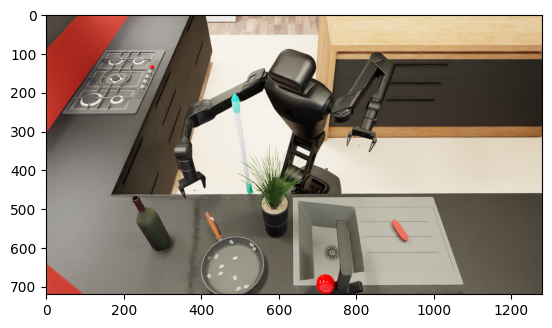

In [163]:
# np.array(f["data"]["demo_0"]["obs"]["robot_r1::robot_r1:left_eef_link:Camera:0::rgb"]).shape
i = 320
path = "/home/arpit/test_projects/mimicgen/paper_assets"
img = f["data"]["demo_0"]["obs"]["viewer_camera_img"][i]
plt.imsave(f'{path}/image_{i}.jpg', img)
plt.imshow(img)
plt.show()

In [57]:
og.sim.viewer_camera.horizontal_aperture = 25.0
# Set camera
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([ 5.473, -2.686,  2.403]),
    orientation=th.tensor([ 0.364, -0.004, -0.004,  0.932])
)
for _ in range(10): og.sim.step()

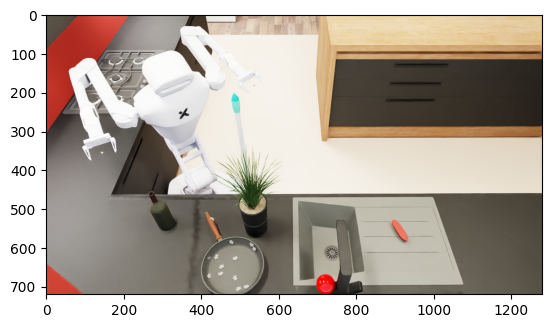

In [58]:
# og.sim.viewer_camera.image_width
viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
plt.imshow(viewer_camera_img)
plt.show()

In [ ]:
np.array(f["data"]["demo_0"]["obs"]["robot_r1::robot_r1:left_eef_link:Camera:0::rgb"]).shape

In [1]:
import json
import h5py
import random
import logging
import omnigibson as og
import torch as th
th.set_printoptions(precision=3, sci_mode=False)
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from omnigibson.macros import create_module_macros
from omnigibson.action_primitives.starter_semantic_action_primitives import StarterSemanticActionPrimitives
import omnigibson.utils.transform_utils as T
from scipy.spatial.transform import Rotation as R
import omnigibson.lazy as lazy
from omnigibson import object_states
from omnigibson.objects.primitive_object import PrimitiveObject
from omnigibson.objects.dataset_object import DatasetObject
import mimicgen.utils.file_utils as MG_FileUtils

def flatten_obs(obs):
    flat_obs = {}

    for top_key, top_val in obs.items():
        if isinstance(top_val, dict):
            for cam_key, cam_val in top_val.items():
                if isinstance(cam_val, dict):
                    for data_key, data_val in cam_val.items():
                        new_key = f"{top_key}::{cam_key}::{data_key}"
                        flat_obs[new_key] = data_val
                else:
                    # In case it's not a dict, fallback to one level key
                    new_key = f"{top_key}::{cam_key}"
                    flat_obs[new_key] = cam_val
        else:
            pass

    return flat_obs

def get_obs(env, robot):
    obs, info = env.get_obs()
    obs = flatten_obs(obs)

    viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
    obs.update({'viewer_camera_img': viewer_camera_img})

    for k in obs.keys():
        if "seg" in k:
            obs[k] = obs[k].cpu()
        else:
            obs[k] = obs[k]
    return obs, info

seed = 0
random.seed(seed)
np.random.seed(seed)
th.manual_seed(seed)

# Load the scene from the hdf5 file
f = h5py.File("/home/arpit/test_projects/OmniGibson/teleop_collected_data/r1_clean_pan.hdf5", "r")
config = f["data"].attrs["config"]
config = json.loads(config)

# Custom changes
config["scene"]["load_room_instances"] = ["kitchen_0", "dining_room_0", "entryway_0", "living_room_0"]
config["robots"][0]["position"] = [0.0, 0.0, 0.0]
config["robots"][0]["orientation"] = [0.0, 0.0, 0.0, 1.0]

RESOLUTION = (256, 256)

# Explicity add the depth_linear and rgb modalities
config["robots"][0]["obs_modalities"].append("depth_linear")
config["robots"][0]["obs_modalities"].append("rgb")
config["robots"][0]["obs_modalities"].append("seg_instance")

# Setting the camera height and width here because setting it later causes issues
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["image_height"] = RESOLUTION[0]
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["image_width"] = RESOLUTION[1]
config["robots"][0]["sensor_config"]["VisionSensor"]["sensor_kwargs"]["horizontal_aperture"] = 25.0

robot_reset_pos = "tuck"
if robot_reset_pos == "untuck":
    config["robots"][0]["reset_joint_pos"] = [
            0.0000,
            0.0000,
            0.000,
            0.000,
            0.000,
            -0.0000, # 6 virtual base joint 
             0.5,
            -1.0,
            -0.8,
            -0.0000, # 4 torso joints
            -0.000,
            0.000,
            1.8944,
            1.8945,
            -0.9848,
            -0.9849,
            1.5612,
            1.5621,
            0.9097,
            0.9096,
            -1.5544,
            -1.5545,
            0.0500,
            0.0500,
            0.0500,
            0.0500,
        ]
elif robot_reset_pos == "tuck":
    # Tucked reset joint positions. The torso is different from the default R1 tucked position
    config["robots"][0]["reset_joint_pos"] = [
            0.0000,
            0.0000,
            0.000,
            0.000,
            0.000,
            -0.0000, # 6 virtual base joint 
             0.5,
            -1.0,
            -0.8,
            -0.0000, # 4 torso joints
            0.0, # left arm joint 1
            0.0, # right arm joint 1
            0.0,
            0.0,
            -0.15,
            -0.15,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0500,
            0.0500,
            0.0500,
            0.0500,
        ] 

env = og.Environment(configs=config)
robot = env.robots[0]
env.reset()

# remove later
obs, info = env.get_obs()

# Set camera
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([ 5.505, -2.686,  2.403]),
    orientation=th.tensor([ 0.404, -0.005, -0.006,  0.915])
)

# Add/Remove objects
obj = env.scene.object_registry("name", "fixed_window_glimdy_0")
obj.visible = False
for eef_link_name in robot.eef_link_names.values():
    robot.links[eef_link_name].visual_meshes["VisualSphere"].visible = False

# Action Diversity: Load 1 pan and three different base pose
pan = env.scene.object_registry("name", "frying_pan_602")
pan.set_position_orientation(th.tensor([5.2, -2.0, 0.908]), th.tensor([    -0.000,      0.000,     -0.499,      0.866]))

# Load distractor objects
# broom-tpyvbt
# mop-qclfvj
distractor_objects = []
obj = DatasetObject(
    name="mop",
    category="mop",
    model="qclfvj",
)
distractor_objects.append(obj)
obj = DatasetObject(
    name="pot_plant",
    category="pot_plant",
    model="cqqyzp",
    scale=th.tensor([1.3, 1.3, 1.3]),
)
distractor_objects.append(obj)
obj = DatasetObject(
    name="wine_bottle",
    category="wine_bottle",
    model="inkqch",
    scale=th.tensor([1.4, 1.4, 1.7])
)
distractor_objects.append(obj)

# Load the objects into the scene
state = og.sim.dump_state()
og.sim.stop()
# Load the objects into the scene
og.sim.batch_add_objects(distractor_objects, [env.scene] * len(distractor_objects))
og.sim.play()
og.sim.load_state(state)

# Set object pose to ensure no collision at spawn time
x_pos = 5.0
for distractor_object in distractor_objects:
    x_pos += 1.0
    distractor_object.set_position_orientation(position=th.tensor([x_pos,  0.0,  0.0]))
og.sim.step()

# obj.set_position_orientation(th.tensor([ 5.318, -1.418,  0.267]), th.tensor([-0.002, -0.001,  0.938,  0.347]))

# Change the color of the robot to be black.
for material in robot.materials:
    material.diffuse_color_constant = th.tensor([0.0, 0.0, 0.0])

# loop over base pose sampling and choose 3 that you like
primitive = StarterSemanticActionPrimitives(
                env,
                env.robots[0],
                enable_head_tracking=False,
                curobo_batch_size=6,
                curobo_use_cuda_graph=False,
                use_base_pose_hack=False,
                real_robot_mode=False,
            )

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


[INFO] [omnigibson.simulator] ----- Starting OmniGibson. This will take 10-30 seconds... -----


ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /home/arpit/test_projects/robomimic/robomimic/scripts/setup_macros.py
)
[Warning] [simulation_app] Interactive python shell detected but ISAAC_JUPYTER_KERNEL was not set. Problems with asyncio may occur
[Warning] [simulation_app] Please use Isaac Sim Python 3 kernel instead of the default Python 3 Kernel
Starting kit application with the following args:  ['/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/isaacsim/exts/isaacsim.simulation_app/isaacsim/simulation_app/simulation_app.py', '/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/isaacsim/apps/omnigibson_4_5_0.kit', '--/app/tokens/exe-path=/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/omni', '--/persistent/app/viewport/displayOptions=3094', '--/rtx/materialDb/syncLoads=True', '--/rtx/hydra/materialSyncLoads=True', '--/omni.

2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 16 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 17 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 18 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 19 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 20 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 21 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 22 belongs to.
2025-05-14 00:25:21 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 23 belongs to.



|---------------------------------------------------------------------------------------------|
| Driver Version: 550.54.14     | Graphics API: Vulkan
|=============================================================================================|
| GPU | Name                             | Active | LDA | GPU Memory | Vendor-ID | LUID       |
|     |                                  |        |     |            | Device-ID | UUID       |
|     |                                  |        |     |            | Bus-ID    |            |
|---------------------------------------------------------------------------------------------|
| 0   | NVIDIA GeForce RTX 4090          | Yes: 0 |     | 24564   MB | 10de      | 0          |
|     |                                  |        |     |            | 2684      | ece2eaa7.. |
|     |                                  |        |     |            | 1         |            |
|===============================================================================

...

2025-05-14 01:13:14 [2,873,305ms] [Warning] [root] 83
2025-05-14 01:13:14 [2,873,306ms] [Warning] [root] 58
2025-05-14 01:13:14 [2,873,306ms] [Warning] [root] 60
2025-05-14 01:13:14 [2,873,307ms] [Warning] [root] 74
2025-05-14 01:13:14 [2,873,307ms] [Warning] [root] 62
2025-05-14 01:13:14 [2,873,308ms] [Warning] [root] 61


2025-05-14 01:14:18 [2,936,431ms] [Warning] [root] 83
2025-05-14 01:14:18 [2,936,431ms] [Warning] [root] 58
2025-05-14 01:14:18 [2,936,432ms] [Warning] [root] 60
2025-05-14 01:14:18 [2,936,432ms] [Warning] [root] 74
2025-05-14 01:14:18 [2,936,432ms] [Warning] [root] 62
2025-05-14 01:14:18 [2,936,433ms] [Warning] [root] 61
graph_success:  6
Arm MP successes:  tensor([True, True, True, True, True, True], device='cuda:0')


2025-05-14 01:24:58 [3,576,356ms] [Warning] [root] 77
2025-05-14 01:24:58 [3,576,357ms] [Warning] [root] 63
2025-05-14 01:24:58 [3,576,357ms] [Warning] [root] 72
2025-05-14 01:24:58 [3,576,357ms] [Warning] [root] 78
2025-05-14 01:24:58 [3,576,358ms] [Warning] [root] 59
2025-05-14 01:24:58 [3,576,358ms] [Warning] [root] 74
graph_success:  6
Arm MP successes:  tensor([True, True, True, True, True, True], device='cuda:0')


2025-05-14 01:31:59 [3,998,071ms] [Warning] [root] 72
2025-05-14 01:31:59 [3,998,071ms] [Warning] [root] 73
2025-05-14 01:31:59 [3,998,071ms] [Warning] [root] 71
2025-05-14 01:31:59 [3,998,072ms] [Warning] [root] 72
2025-05-14 01:31:59 [3,998,072ms] [Warning] [root] 72
2025-05-14 01:31:59 [3,998,072ms] [Warning] [root] 72


2025-05-14 01:34:09 [4,128,142ms] [Warning] [root] 72
2025-05-14 01:34:09 [4,128,143ms] [Warning] [root] 73
2025-05-14 01:34:09 [4,128,143ms] [Warning] [root] 71
2025-05-14 01:34:09 [4,128,144ms] [Warning] [root] 72
2025-05-14 01:34:09 [4,128,144ms] [Warning] [root] 72
2025-05-14 01:34:09 [4,128,144ms] [Warning] [root] 72
graph_success:  6
Arm MP successes:  tensor([True, True, True, True, True, True], device='cuda:0')
graph_success:  6
Arm MP successes:  tensor([False,  True,  True,  True,  True,  True], device='cuda:0')


In [114]:
pan.set_position_orientation(th.tensor([5.2, -2.0, 0.908]), th.tensor([    -0.000,      0.000,     -0.499,      0.866]))

mop = env.scene.object_registry("name", "mop")
orientation = th.tensor([-0.002, -0.001,  0.938,  0.347])
rot_z = R.from_euler('z', 60, degrees=True)
original_rot = R.from_quat(orientation)
new_rot = rot_z * original_rot
rotated_quat = new_rot.as_quat()
mop.set_position_orientation(th.tensor([ 5.218, -1.418,  0.267]), rotated_quat)

pot_plant = env.scene.object_registry("name", "pot_plant")
# pot_plant.set_position_orientation(th.tensor([ 5.072, -2.083,  1.083]), th.tensor([    -0.000,     -0.000,      0.953,      0.303]))
pot_plant.set_position_orientation(th.tensor([ 5.4, -1.8,  1.083]), th.tensor([    -0.000,     -0.000,      0.953,      0.303]))

wine_bottle = env.scene.object_registry("name", "wine_bottle")
wine_bottle.set_position_orientation(th.tensor([ 4.838, -1.872,  1.079]), th.tensor([    -0.000,      0.000,     -0.997,      0.079]))

In [118]:
state = og.sim.dump_state()
og.sim.stop()
wine_bottle.scale = th.tensor([1.4, 1.4, 1.7])

og.sim.play()
og.sim.load_state(state)
for _ in range(50): og.sim.step()
# wine_bottle.set_position_orientation(th.tensor([ 4.838, -1.872,  1.279]), th.tensor([    -0.000,      0.000,     -0.997,      0.079]))
# for _ in range(50): og.sim.step()


In [115]:
for _ in range(50): og.sim.step()

In [17]:
pot_plant.set_position_orientation(th.tensor([ 5.3, -1.8,  1.083]), th.tensor([    -0.000,     -0.000,      0.953,      0.303]))
# pan.set_position_orientation(th.tensor([5.2, -2.0, 0.908]), th.tensor([    -0.000,      0.000,     -0.499,      0.866]))

In [66]:
for _ in range(50): og.sim.step()

In [ ]:
robot.get_position_orientation()

In [154]:

# =========== Finding robot base pose ============
eef_pose = {'right': (
        th.tensor([[ 5.046, -1.725,  1.092],
    [ 5.036, -1.713,  1.016],
    [ 5.077, -1.700,  0.985],
    [ 5.034, -1.684,  0.973],
    [ 5.061, -1.707,  0.975],
    [ 5.081, -1.705,  0.941],
    [ 5.090, -1.705,  0.948],
    [ 5.220, -1.736,  1.046]]), 
        th.tensor([[ 0.927, -0.357,  0.071,  0.089],
    [ 0.926, -0.370,  0.068,  0.044],
    [ 0.933, -0.346,  0.094, -0.025],
    [ 0.916, -0.390,  0.090, -0.015],
    [ 0.933, -0.351,  0.079, -0.014],
    [ 0.933, -0.347,  0.091, -0.036],
    [ 0.916, -0.388,  0.092, -0.049],
    [ 0.800, -0.590,  0.110, -0.017]])
)}
# for _ in range(1):
#     base_pose2d = primitive._sample_pose_near_object(pan, eef_pose, skip_obstacle_update=False, visibility_constraint=False)
#     if base_pose2d is None:
#         continue
#     base_pose = primitive._get_robot_pose_from_2d_pose(base_pose2d)
#     base_pose
#     robot.set_position_orientation(base_pose[0], base_pose[1])
#     for _ in range(10): og.sim.step()
#     breakpoint()


# =========== Setting robot base pose ============
# Base pose 1 (middle)
# base_pose = (th.tensor([ 5.254, -0.980, -0.019]), th.tensor([ 0.005, -0.002, -0.727,  0.686]))

# Base pose 2 (left)
# base_pose = (th.tensor([ 4.796, -1.171, -0.019]), th.tensor([     0.005,      0.000,     -0.444,      0.896]))

# # Base pose 3 (right)
base_pose = (th.tensor([ 5.605, -1.164, -0.019]), th.tensor([ 0.004, -0.003, -0.882,  0.471]))

robot.set_position_orientation(base_pose[0], base_pose[1])
for _ in range(10): og.sim.step()
# ==================================================

In [25]:
seed = 1
random.seed(seed)
np.random.seed(seed)
th.manual_seed(seed)

In [156]:
target_pos = {'right_eef_link': th.tensor([ 5.046, -1.725,  1.092],)} 
target_quat = {'right_eef_link': th.tensor([ 0.927, -0.357,  0.071,  0.089])}

emb_sel = "arm_no_torso"
new_target_pos = {k: th.stack([v for _ in range(primitive._motion_generator.batch_size)]) for k, v in target_pos.items()}
new_target_quat = {k: th.stack([v for _ in range(primitive._motion_generator.batch_size)]) for k, v in target_quat.items()}
mp_results, traj_paths = primitive._motion_generator.compute_trajectories(
    target_pos=new_target_pos,
    target_quat=new_target_quat,
    is_local=False,
    max_attempts=50,
    timeout=60.0,
    ik_fail_return=10,
    enable_finetune_trajopt=True,
    finetune_attempts=1,
    return_full_result=True,
    success_ratio=1.0 / primitive._motion_generator.batch_size,
    attached_obj=None,
    attached_obj_scale=None,
    emb_sel=emb_sel,
    eyes_target_pos=None,
    eyes_target_quat=None,
)
successes = mp_results[0].success 
print("Arm MP successes: ", successes)
success_idx = th.where(successes)[0].cpu()
if len(success_idx) == 0:
    breakpoint()
else:
    traj_path = traj_paths[success_idx[0]]

In [128]:
for i in range(6): logging.warning(len(traj_paths[i]))
# successes

[WARNING] [root] 72
[WARNING] [root] 73
[WARNING] [root] 71
[WARNING] [root] 72
[WARNING] [root] 72
[WARNING] [root] 72


In [157]:
# traj_path = traj_paths[0]
use_arm = "right"
q_traj = primitive._motion_generator.path_to_joint_trajectory(traj_path, get_full_js=True, emb_sel=emb_sel)
q_traj = th.stack(primitive._add_linearly_interpolated_waypoints(plan=q_traj, max_inter_dist=0.01))
q_traj = q_traj.cpu()
mp_actions = []
for j_pos in q_traj:
    if use_arm == "right":
        j_pos[robot.arm_control_idx["left"]] = robot.get_joint_positions()[robot.arm_control_idx["left"]]
    elif use_arm == "left":
        j_pos[robot.arm_control_idx["right"]] = robot.get_joint_positions()[robot.arm_control_idx["right"]]

    action = robot.q_to_action(j_pos).cpu().numpy()
    mp_actions.append(action)

In [158]:
# breakpoint()
original_state = og.sim.dump_state(serialized=True)
states, actions, observations, observations_info = [], [], [], []
for i, mp_action in enumerate(mp_actions):
    state = og.sim.dump_state(serialized=True)
    obs, obs_info = get_obs(env, robot)
    # TODO: Check if we can use primtiive stack execute action here. This will allow for checking convergence errors etc.
    env.step(mp_action)
    states.append(state)
    actions.append(mp_action)
    observations.append(obs)
    observations_info.append(json.dumps(obs_info))

In [159]:
tmp_dataset_folder_path = "/home/arpit/test_projects/mimicgen/random_files"
MG_FileUtils.write_demo_to_hdf5(
    folder=tmp_dataset_folder_path,
    env=None,
    initial_state=dict(state=states[0]),
    states=states,
    observations=observations,
    observations_info=None,
    datagen_info=None,
    actions=np.array(actions),
)


In [153]:
og.sim.load_state(original_state, serialized=True)
for _ in range(50): og.sim.step()